In [7]:
import pandas as pd
import numpy as np
import random
import json
from collections import defaultdict

np.random.seed(42)
random.seed(42)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH   = "../arxiv_dataset/arxiv_ai_ml_papers.csv"   # thay bằng path dataset thực tế
OUTPUT_PATH = "synthetic_users.json"

# ── Generation config ────────────────────────────────────────────────────────
N_USERS        = 1000
N_NEGATIVES    = 6     # số negative papers / user cho LTR
TRAIN_RATIO    = 0.8

In [8]:
df = pd.read_csv(DATA_PATH)

print(f"Total papers : {len(df):,}")
print(f"Columns      : {list(df.columns)}")
print(f"\nCategory distribution (top 15):")
print(df['primary_category'].value_counts().head(15))

Total papers : 7,701
Columns      : ['paper_id', 'title', 'authors', 'num_authors', 'first_author', 'abstract', 'abstract_length', 'word_count', 'primary_category', 'all_categories', 'num_categories', 'submitted_date', 'updated_date', 'year', 'month', 'has_journal_ref', 'journal_ref', 'comment', 'has_doi', 'doi', 'arxiv_url', 'pdf_url', 'is_large_collaboration', 'is_updated', 'update_lag_days', 'days_since_submission']

Category distribution (top 15):
primary_category
cs.CV      1418
cs.LG      1392
cs.CL      1119
cs.RO       633
cs.AI       555
cs.NE       511
cs.IR       456
stat.ML     398
cs.CR       149
cs.SE        93
stat.ME      78
cs.HC        59
math.OC      55
cs.CY        46
cs.SD        46
Name: count, dtype: int64


In [9]:
# Build index: category → list of paper_ids (để sample nhanh)
cat_to_papers = defaultdict(list)
for _, row in df.iterrows():
    cat_to_papers[row['primary_category']].append(row['paper_id'])

all_categories = list(cat_to_papers.keys())
print(f"Unique primary categories: {len(all_categories)}")
print(all_categories)

Unique primary categories: 107
['cs.CL', 'cs.IR', 'cs.CV', 'cs.RO', 'eess.IV', 'cs.DS', 'eess.SY', 'cs.HC', 'math.PR', 'cs.IT', 'cs.NE', 'cs.SD', 'cs.LG', 'stat.ME', 'cs.CR', 'cs.DC', 'stat.ML', 'nlin.CD', 'quant-ph', 'math.CO', 'eess.AS', 'cs.SE', 'math.OC', 'cs.AI', 'cs.MA', 'cs.CE', 'cond-mat.mtrl-sci', 'cs.CY', 'eess.SP', 'cs.LO', 'cs.AR', 'cs.DL', 'q-bio.NC', 'cond-mat.str-el', 'econ.EM', 'cs.NI', 'math.NA', 'cs.GR', 'math.ST', 'q-bio.QM', 'cs.DB', 'math.DS', 'stat.AP', 'astro-ph.HE', 'hep-ph', 'physics.acc-ph', 'physics.comp-ph', 'physics.data-an', 'q-bio.BM', 'cs.GT', 'physics.flu-dyn', 'cs.SI', 'q-bio.MN', 'physics.chem-ph', 'cond-mat.quant-gas', 'math.DG', 'cs.CC', 'astro-ph.CO', 'cs.ET', 'q-bio.OT', 'physics.geo-ph', 'math.NT', 'math.MG', 'math.GR', 'astro-ph.IM', 'econ.GN', 'cs.SC', 'physics.ao-ph', 'econ.TH', 'physics.soc-ph', 'physics.ed-ph', 'cs.MM', 'q-bio.PE', 'hep-ex', 'math.AP', 'cs.PL', 'q-fin.PM', 'q-fin.ST', 'q-bio.GN', 'q-fin.GN', 'physics.space-ph', 'physics.med-

In [11]:
USER_ARCHETYPES = {
    "CV_researcher": {
        "primary"  : ["cs.CV"],
        "secondary": ["cs.LG", "cs.RO"],
    },
    "NLP_researcher": {
        "primary"  : ["cs.CL"],
        "secondary": ["cs.IR", "cs.LG", "cs.AI"],
    },
    "ML_theorist": {
        "primary"  : ["cs.LG", "stat.ML"],
        "secondary": ["cs.AI", "math.OC"],
    },
    "AI_researcher": {
        "primary"  : ["cs.AI"],
        "secondary": ["cs.LG", "cs.CL"],
    },
    "multimodal_researcher": {
        "primary"  : ["cs.CV", "cs.CL"],
        "secondary": ["cs.LG", "cs.AI"],
    },
}

# Lọc chỉ giữ các category có tồn tại trong dataset
def filter_available_cats(cat_list):
    return [c for c in cat_list if c in cat_to_papers]

for name, arch in USER_ARCHETYPES.items():
    arch['primary']   = filter_available_cats(arch['primary'])
    arch['secondary'] = filter_available_cats(arch['secondary'])
    print(f"{name:30s} | primary={arch['primary']} | secondary={arch['secondary']}")

CV_researcher                  | primary=['cs.CV'] | secondary=['cs.LG', 'cs.RO']
NLP_researcher                 | primary=['cs.CL'] | secondary=['cs.IR', 'cs.LG', 'cs.AI']
ML_theorist                    | primary=['cs.LG', 'stat.ML'] | secondary=['cs.AI', 'math.OC']
AI_researcher                  | primary=['cs.AI'] | secondary=['cs.LG', 'cs.CL']
multimodal_researcher          | primary=['cs.CV', 'cs.CL'] | secondary=['cs.LG', 'cs.AI']


In [12]:
USER_TYPES = {
    "new_user"   : {"n_papers_range": (3,  8),  "weight": 0.20},  # cold-ish start
    "regular"    : {"n_papers_range": (10, 25), "weight": 0.50},  # main segment
    "power_user" : {"n_papers_range": (30, 60), "weight": 0.30},  # heavy reader
}

USER_TYPE_NAMES   = list(USER_TYPES.keys())
USER_TYPE_WEIGHTS = [USER_TYPES[t]['weight'] for t in USER_TYPE_NAMES]

In [13]:
def sample_papers_for_archetype(archetype: dict, n_papers: int) -> list:
    """
    Sample paper_ids theo phân bổ category của archetype.
    - 70% từ primary categories
    - 20% từ secondary categories (nếu có)
    - 10% random noise
    """
    papers = []
    
    n_primary   = max(1, int(n_papers * 0.70))
    n_secondary = max(0, int(n_papers * 0.20)) if archetype['secondary'] else 0
    n_noise     = n_papers - n_primary - n_secondary

    # Primary
    primary_pool = []
    for cat in archetype['primary']:
        primary_pool.extend(cat_to_papers.get(cat, []))
    if primary_pool:
        papers += random.choices(primary_pool, k=n_primary)

    # Secondary
    if n_secondary > 0:
        secondary_pool = []
        for cat in archetype['secondary']:
            secondary_pool.extend(cat_to_papers.get(cat, []))
        if secondary_pool:
            papers += random.choices(secondary_pool, k=n_secondary)

    # Noise
    if n_noise > 0:
        noise_pool = df['paper_id'].tolist()
        papers += random.choices(noise_pool, k=n_noise)

    # Deduplicate (giữ nguyên thứ tự, bỏ duplicate)
    seen = set()
    unique_papers = []
    for p in papers:
        if p not in seen:
            seen.add(p)
            unique_papers.append(p)

    # Nếu sau dedup còn thiếu thì sample thêm random
    while len(unique_papers) < n_papers:
        extra = random.choice(df['paper_id'].tolist())
        if extra not in seen:
            seen.add(extra)
            unique_papers.append(extra)

    return unique_papers

In [14]:
def generate_days_ago(n_papers: int) -> list:
    """
    Sinh `days_ago` cho từng paper trong reading history.

    Convention:
      - Paper cuối cùng (mới nhất, sẽ bị giấu trong LOO) → days_ago = 0
      - Các paper trước đó → days_ago tăng dần (đọc xa hơn trong quá khứ)
      - Phân bố: exponential với scale=45 → tập trung vào 90 ngày gần nhất,
        tối đa 180 ngày (6 tháng) để phù hợp timespan của dataset (Sep25–Apr26)
    """
    if n_papers == 1:
        return [0]

    # n_papers - 1 khoảng cách giữa các lần đọc liên tiếp
    # Dùng exponential để có reading sessions (đọc dồn rồi nghỉ)
    gaps = np.random.exponential(scale=45 / (n_papers - 1), size=n_papers - 1)
    gaps = np.clip(gaps, 0.5, None)   # tối thiểu 0.5 ngày giữa 2 lần đọc

    # days_ago của paper thứ i tính từ paper cuối
    # Paper cuối = 0, paper trước đó = gap[-1], ...
    cumulative = np.cumsum(gaps[::-1])[::-1]  # reverse cumsum
    days_ago   = np.append(cumulative, 0)     # paper cuối = 0
    days_ago   = np.clip(days_ago, 0, 180).astype(int).tolist()

    return days_ago

In [15]:
def split_loo(reading_history: list) -> tuple:
    """
    Leave-One-Out split: giấu paper CUỐI CÙNG (days_ago = 0, tức mới nhất).
    
    Trả về:
      train_history : list of (paper_id, days_ago) — dùng để build user profile
      target_paper  : paper_id                     — ground truth cho evaluation
    """
    # reading_history đã được sắp xếp theo days_ago giảm dần
    # → phần tử cuối = paper mới nhất (days_ago = 0)
    train_history = reading_history[:-1]
    target_paper  = reading_history[-1][0]   # chỉ lấy paper_id
    return train_history, target_paper


def get_negative_papers(target_paper_id: str, archetype: dict, n: int) -> list:
    """
    Sample negative papers cho LTR training:
    - Ưu tiên lấy từ các category KHÁC với primary của archetype
      → tạo contrast rõ ràng để LTR học được
    """
    primary_cats = set(archetype['primary'])
    negative_pool = [
        pid for pid, row in zip(df['paper_id'], df.itertuples())
        if pid != target_paper_id and row.primary_category not in primary_cats
    ]

    if len(negative_pool) < n:
        negative_pool = [pid for pid in df['paper_id'] if pid != target_paper_id]

    return random.sample(negative_pool, min(n, len(negative_pool)))

In [16]:
def generate_synthetic_users(n_users: int = N_USERS) -> list:
    """
    Generate N synthetic users.

    Mỗi user là một dict:
    {
        "user_id"       : str,
        "archetype"     : str,
        "user_type"     : str,
        "train_history" : [(paper_id, days_ago), ...],   # sorted: oldest → newest
        "target_paper"  : str,                           # LOO held-out paper
        "negative_papers": [paper_id, ...],              # for LTR training
    }
    """
    users = []
    archetype_names = list(USER_ARCHETYPES.keys())

    for i in range(n_users):
        # ── 1. Sample archetype & user type ───────────────────────────────
        archetype_name = random.choice(archetype_names)
        archetype      = USER_ARCHETYPES[archetype_name]

        user_type_name = random.choices(USER_TYPE_NAMES, weights=USER_TYPE_WEIGHTS, k=1)[0]
        n_papers_range = USER_TYPES[user_type_name]['n_papers_range']
        n_papers       = random.randint(*n_papers_range)

        # Đảm bảo đủ paper để LOO (cần ít nhất 2: 1 train + 1 target)
        n_papers = max(n_papers, 2)

        # ── 2. Sample papers theo archetype ───────────────────────────────
        paper_ids = sample_papers_for_archetype(archetype, n_papers)

        # ── 3. Gán days_ago (temporal realism) ────────────────────────────
        days_ago_list = generate_days_ago(len(paper_ids))

        # Ghép lại và sort theo days_ago GIẢM dần → tăng dần
        # (paper cũ nhất đầu tiên, paper mới nhất = 0 ở cuối)
        reading_history = sorted(
            list(zip(paper_ids, days_ago_list)),
            key=lambda x: x[1],
            reverse=True   # oldest first
        )

        # ── 4. Leave-One-Out split ─────────────────────────────────────────
        train_history, target_paper = split_loo(reading_history)

        # ── 5. Sample negatives (for LTR training) ─────────────────────────
        negatives = get_negative_papers(target_paper, archetype, n=N_NEGATIVES)

        users.append({
            "user_id"        : f"user_{i:04d}",
            "archetype"      : archetype_name,
            "user_type"      : user_type_name,
            "train_history"  : [(pid, int(d)) for pid, d in train_history],
            "target_paper"   : target_paper,
            "negative_papers": negatives,
        })

    return users


print("Generating synthetic users...")
users = generate_synthetic_users(N_USERS)
print(f"✓ Generated {len(users)} users")

Generating synthetic users...
✓ Generated 1000 users


In [18]:
# Xem một user mẫu
sample = users[1]
print(f"user_id      : {sample['user_id']}")
print(f"archetype    : {sample['archetype']}")
print(f"user_type    : {sample['user_type']}")
print(f"history size : {len(sample['train_history'])} papers")
print(f"target_paper : {sample['target_paper']}")
print(f"\ntrain_history (oldest → newest):")
for pid, d in sample['train_history']:
    print(f"  paper_id={pid:20s}  days_ago={d}")
print(f"\nnegative_papers: {sample['negative_papers']}")

user_id      : user_0001
archetype    : NLP_researcher
user_type    : regular
history size : 9 papers
target_paper : 2604.17808v1

train_history (oldest → newest):
  paper_id=2604.16625v1          days_ago=49
  paper_id=2604.12770v1          days_ago=49
  paper_id=2604.14315v1          days_ago=48
  paper_id=2604.18914v1          days_ago=47
  paper_id=2604.17828v1          days_ago=37
  paper_id=2604.20199v1          days_ago=33
  paper_id=2604.10316v1          days_ago=26
  paper_id=2510.23323v2          days_ago=26
  paper_id=2603.17580v1          days_ago=8

negative_papers: ['2604.19930v2', '2604.23025v1', '2604.20211v1', '2512.07142v1', '2604.18803v3', '2604.24662v1']


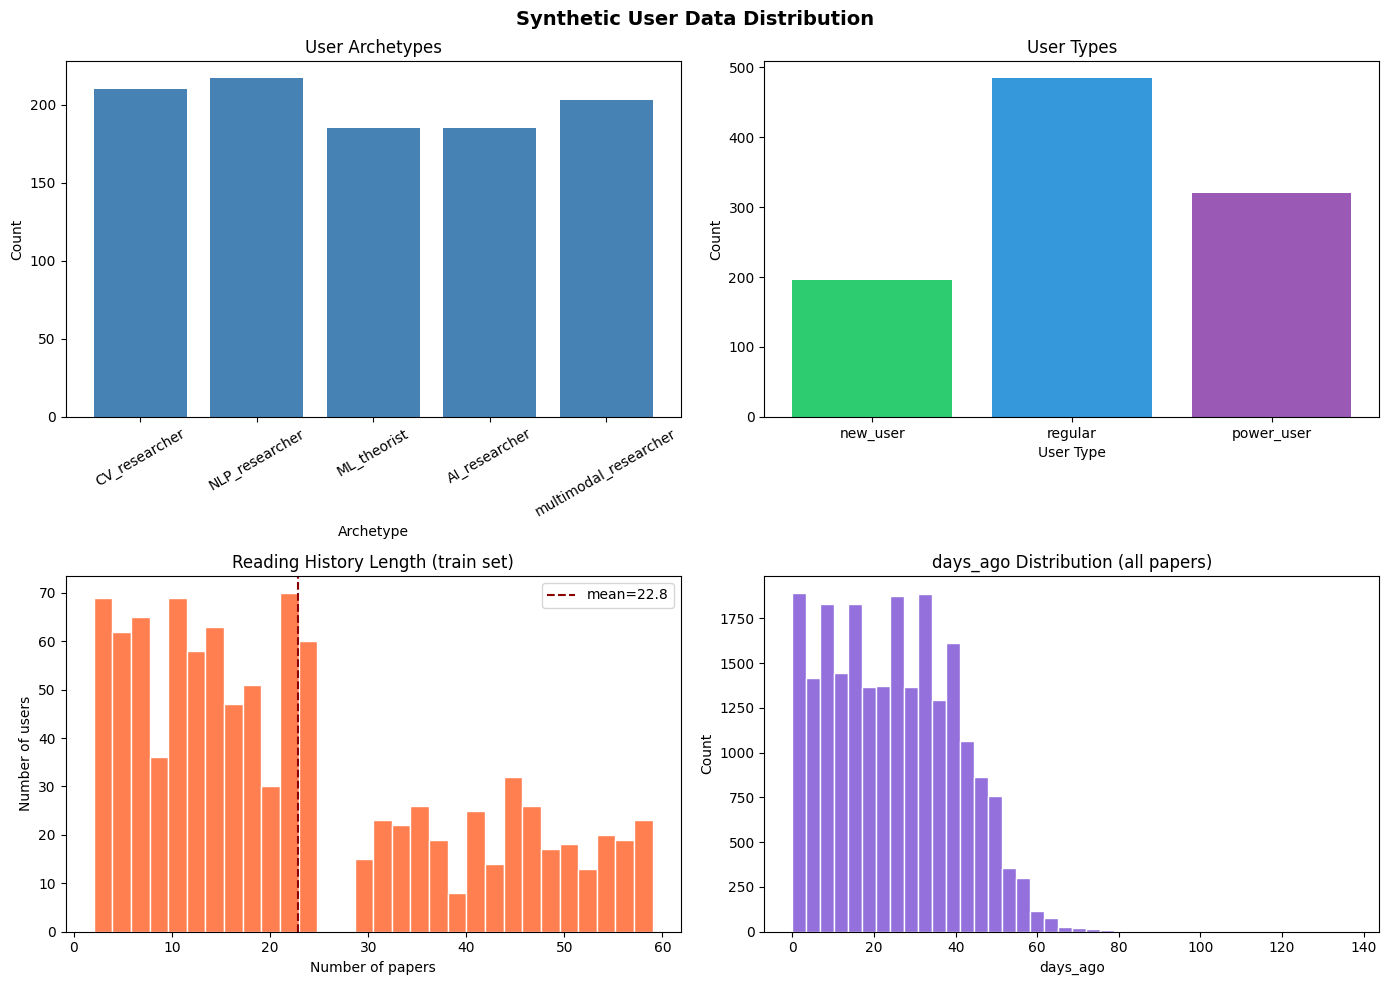

✓ Saved: user_generation_stats.png


In [20]:
import matplotlib.pyplot as plt

# ── 7.1 Archetype distribution ─────────────────────────────────────────────
archetype_counts = defaultdict(int)
for u in users:
    archetype_counts[u['archetype']] += 1

# ── 7.2 User type distribution ─────────────────────────────────────────────
usertype_counts = defaultdict(int)
for u in users:
    usertype_counts[u['user_type']] += 1

# ── 7.3 History length distribution ────────────────────────────────────────
history_lengths = [len(u['train_history']) for u in users]

# ── 7.4 days_ago distribution (flatten tất cả) ─────────────────────────────
all_days_ago = [d for u in users for _, d in u['train_history']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Synthetic User Data Distribution', fontsize=14, fontweight='bold')

# Plot 1: Archetype
axes[0,0].bar(archetype_counts.keys(), archetype_counts.values(), color='steelblue')
axes[0,0].set_title('User Archetypes')
axes[0,0].set_xlabel('Archetype')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=30)

# Plot 2: User type
axes[0,1].bar(usertype_counts.keys(), usertype_counts.values(),
              color=['#2ecc71', '#3498db', '#9b59b6'])
axes[0,1].set_title('User Types')
axes[0,1].set_xlabel('User Type')
axes[0,1].set_ylabel('Count')

# Plot 3: History length
axes[1,0].hist(history_lengths, bins=30, color='coral', edgecolor='white')
axes[1,0].set_title('Reading History Length (train set)')
axes[1,0].set_xlabel('Number of papers')
axes[1,0].set_ylabel('Number of users')
axes[1,0].axvline(np.mean(history_lengths), color='darkred', linestyle='--',
                  label=f'mean={np.mean(history_lengths):.1f}')
axes[1,0].legend()

# Plot 4: days_ago
axes[1,1].hist(all_days_ago, bins=40, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('days_ago Distribution (all papers)')
axes[1,1].set_xlabel('days_ago')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
#plt.savefig('user_generation_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: user_generation_stats.png")

In [21]:
# ── Summary stats ─────────────────────────────────────────────────────────
print("=" * 50)
print("GENERATION SUMMARY")
print("=" * 50)
print(f"Total users generated  : {len(users)}")
print(f"\nArchetype breakdown:")
for k, v in sorted(archetype_counts.items()):
    print(f"  {k:30s}: {v}")
print(f"\nUser type breakdown:")
for k, v in sorted(usertype_counts.items()):
    print(f"  {k:15s}: {v}")
print(f"\nHistory length stats:")
print(f"  min    : {min(history_lengths)}")
print(f"  max    : {max(history_lengths)}")
print(f"  mean   : {np.mean(history_lengths):.2f}")
print(f"  median : {np.median(history_lengths):.1f}")
print(f"\ndays_ago stats:")
print(f"  min    : {min(all_days_ago)}")
print(f"  max    : {max(all_days_ago)}")
print(f"  mean   : {np.mean(all_days_ago):.2f}")

GENERATION SUMMARY
Total users generated  : 1000

Archetype breakdown:
  AI_researcher                 : 185
  CV_researcher                 : 210
  ML_theorist                   : 185
  NLP_researcher                : 217
  multimodal_researcher         : 203

User type breakdown:
  new_user       : 196
  power_user     : 320
  regular        : 484

History length stats:
  min    : 2
  max    : 59
  mean   : 22.81
  median : 19.0

days_ago stats:
  min    : 0
  max    : 137
  mean   : 24.71


In [22]:
random.shuffle(users)
split_idx   = int(N_USERS * TRAIN_RATIO)
train_users = users[:split_idx]
test_users  = users[split_idx:]

print(f"Train users : {len(train_users)}  → {len(train_users) * N_NEGATIVES} LTR pairwise samples")
print(f"Test users  : {len(test_users)}   → for NDCG@K, Precision@K evaluation")

Train users : 800  → 4800 LTR pairwise samples
Test users  : 200   → for NDCG@K, Precision@K evaluation


In [23]:
output = {
    "meta": {
        "n_users"      : N_USERS,
        "n_negatives"  : N_NEGATIVES,
        "train_ratio"  : TRAIN_RATIO,
        "n_train"      : len(train_users),
        "n_test"       : len(test_users),
        "random_seed"  : 42,
    },
    "train": train_users,
    "test" : test_users,
}

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"✓ Saved to: {OUTPUT_PATH}")
print(f"  File size: {__import__('os').path.getsize(OUTPUT_PATH) / 1024:.1f} KB")

✓ Saved to: synthetic_users.json
  File size: 1789.1 KB


In [24]:
errors = []

for u in users:
    uid = u['user_id']

    # 1. Phải có ít nhất 1 paper trong train_history
    if len(u['train_history']) < 1:
        errors.append(f"{uid}: train_history rỗng")

    # 2. target_paper không được nằm trong train_history
    train_ids = {pid for pid, _ in u['train_history']}
    if u['target_paper'] in train_ids:
        errors.append(f"{uid}: target_paper bị leak vào train_history")

    # 3. days_ago phải tăng dần từ cuối lên đầu (oldest first)
    days = [d for _, d in u['train_history']]
    if days != sorted(days, reverse=True):
        errors.append(f"{uid}: days_ago không được sort đúng")

    # 4. Không có negative nào trùng target
    if u['target_paper'] in u['negative_papers']:
        errors.append(f"{uid}: target_paper nằm trong negative_papers")

    # 5. days_ago trong range hợp lệ
    invalid = [(pid, d) for pid, d in u['train_history'] if d < 0 or d > 180]
    if invalid:
        errors.append(f"{uid}: days_ago ngoài range [0, 180]: {invalid}")

if errors:
    print(f"❌ Found {len(errors)} issues:")
    for e in errors[:10]:
        print(f"  - {e}")
else:
    print(f"✓ All {len(users)} users passed sanity checks")

✓ All 1000 users passed sanity checks
